# EDA: Adult Census Income Dataset
**ML-MDS 2026. Elisa Müller & Berta Torrents**

This notebook covers the Exploratory Data Analysis.

Sections:
1. Setup & Data Loading
2. First Look (shape, types, sample rows)
3. Missing Values
4. Target Variable
5. Numerical Features
6. Categorical Features
7. Feature Relationships
8. Preprocessing Notes

## 1. Setup & Data Loading

In [49]:
%pip install numpy pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
df = pd.read_csv('adult.csv', na_values='?')

df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('.', '_')
df = df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income']


## 2. First Look

In [52]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [68]:
TARGET = 'income'

# Derive numerical and categorical columns automatically
NUM_COLS = df.select_dtypes(include='number').columns.tolist()
CAT_COLS = [c for c in df.select_dtypes(include=['object', 'string']).columns if c != TARGET]

print('Numerical :', NUM_COLS)
print('Categorical:', CAT_COLS)
print('Target     :', TARGET)

Numerical : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Target     : income


## 3. Missing Values

In [55]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('count', ascending=False)
print(missing_df)

rows_with_any_missing = df.isnull().any(axis=1).sum()
print(f'\nRows with at least one missing value: {rows_with_any_missing} ({rows_with_any_missing/len(df)*100:.1f}%)')

                count   pct
occupation       1843 5.660
workclass        1836 5.640
native_country    583 1.790

Rows with at least one missing value: 2399 (7.4%)


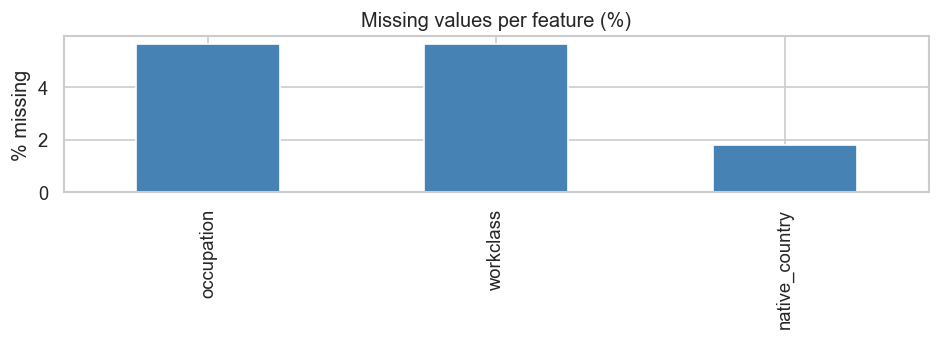

In [56]:
fig, ax = plt.subplots(figsize=(8, 3))
missing_df['pct'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Missing values per feature (%)')
ax.set_ylabel('% missing')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. Target Variable

In [57]:
target_counts = df[TARGET].value_counts()
target_pct = df[TARGET].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': target_counts, 'pct': target_pct.round(1)}))

        count    pct
income              
<=50K   24720 75.900
>50K     7841 24.100


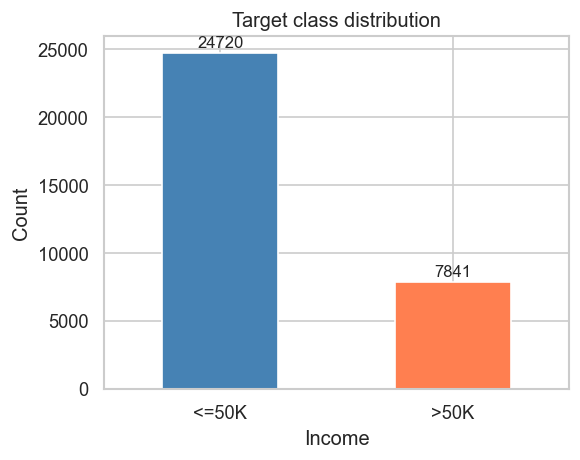

In [58]:
fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target class distribution')
ax.set_xlabel('Income')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

> **Note**: The dataset is imbalanced — roughly 3:1 in favour of `<=50K`. This will matter for metric choice (prefer F1, ROC-AUC, AUPR over accuracy) and may require stratified splits or resampling.

## 5. Numerical Features

In [59]:
df[NUM_COLS].describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000,32561.000,32561.000,32561.000,32561.000,32561.000
mean,38.582,189778.367,10.081,1077.649,87.304,40.437
std,13.640,105549.978,2.573,7385.292,402.960,12.347
min,17.000,12285.000,1.000,0.000,0.000,1.000
25%,28.000,117827.000,9.000,0.000,0.000,40.000
50%,37.000,178356.000,10.000,0.000,0.000,40.000
75%,48.000,237051.000,12.000,0.000,0.000,45.000
max,90.000,1484705.000,16.000,99999.000,4356.000,99.000


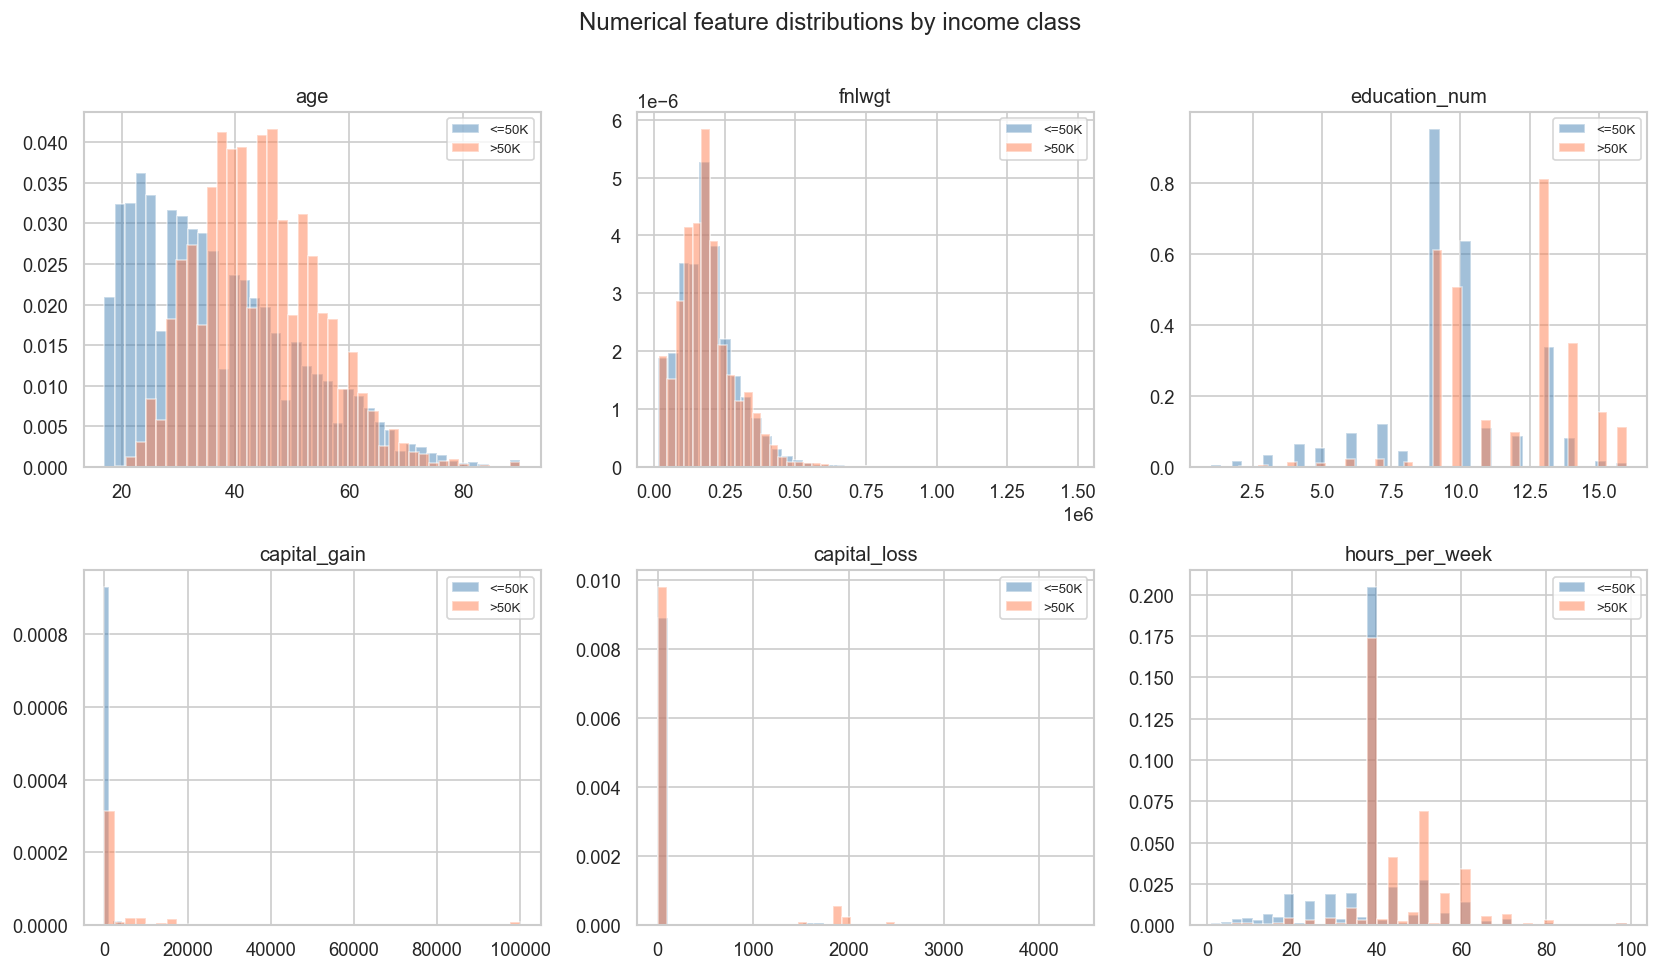

In [60]:
# Distributions
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for label, color in [('<=50K', 'steelblue'), ('>50K', 'coral')]:
        subset = df.loc[df[TARGET] == label, col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, label=label, color=color, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Numerical feature distributions by income class', y=1.01)
plt.tight_layout()
plt.show()

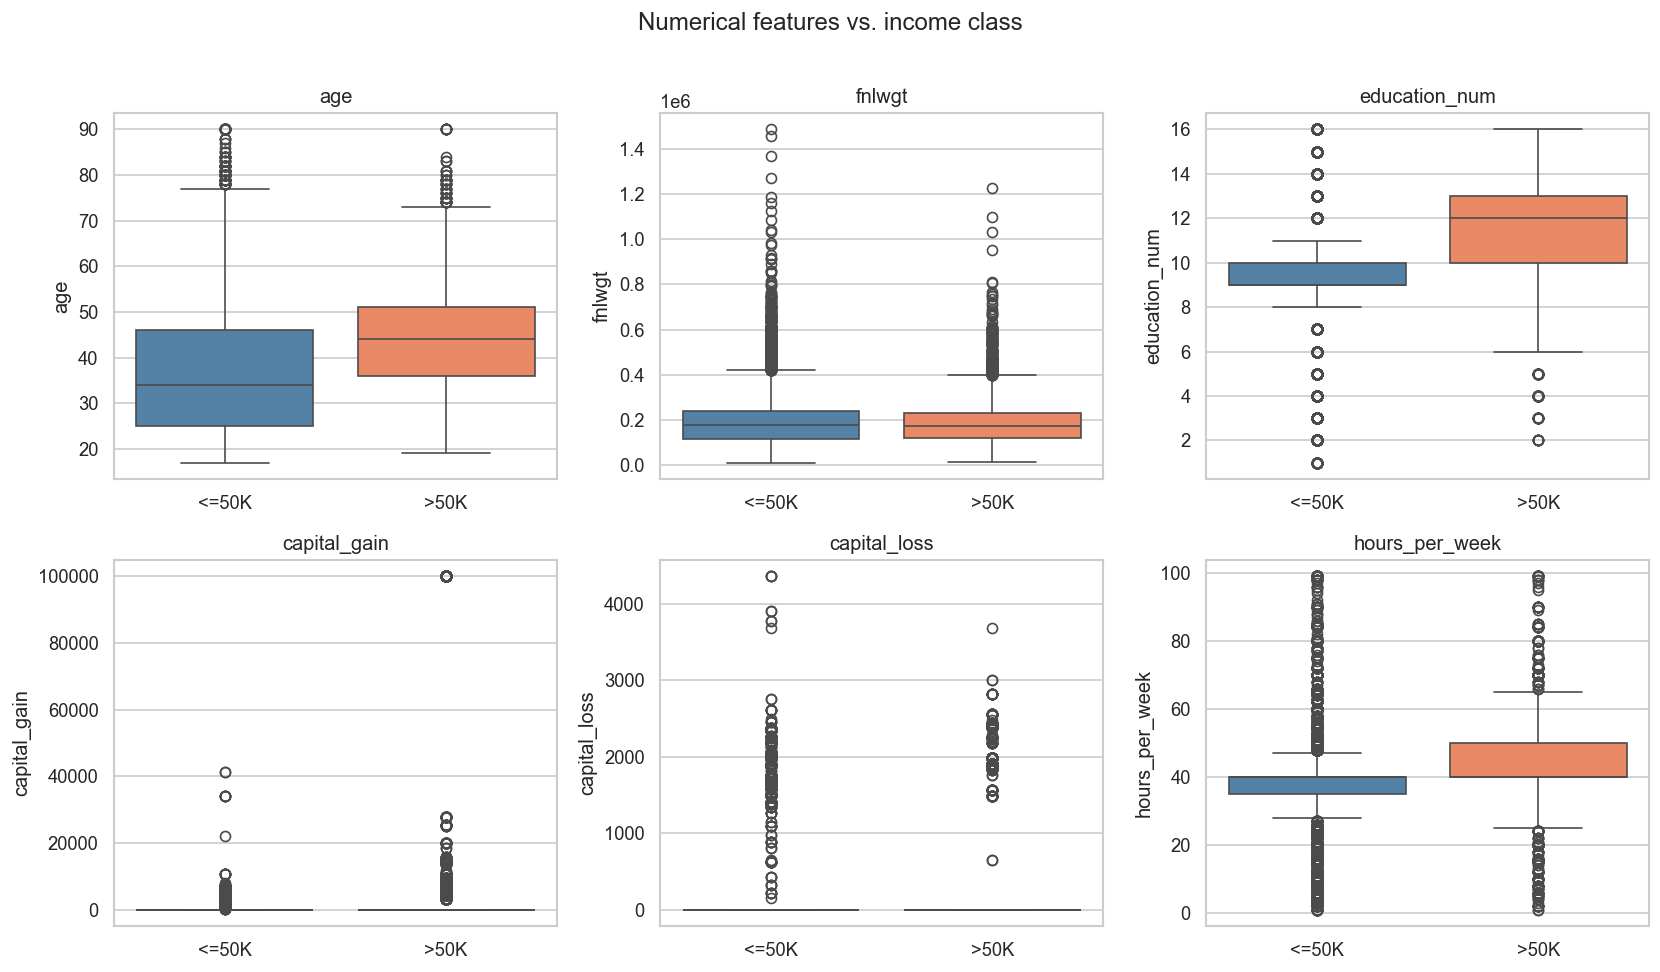

In [69]:
# Boxplots — good for spotting skew and outliers
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, ax=axes[i], palette=['steelblue', 'coral'], legend=False)
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Numerical features vs. income class', y=1.01)
plt.tight_layout()
plt.show()

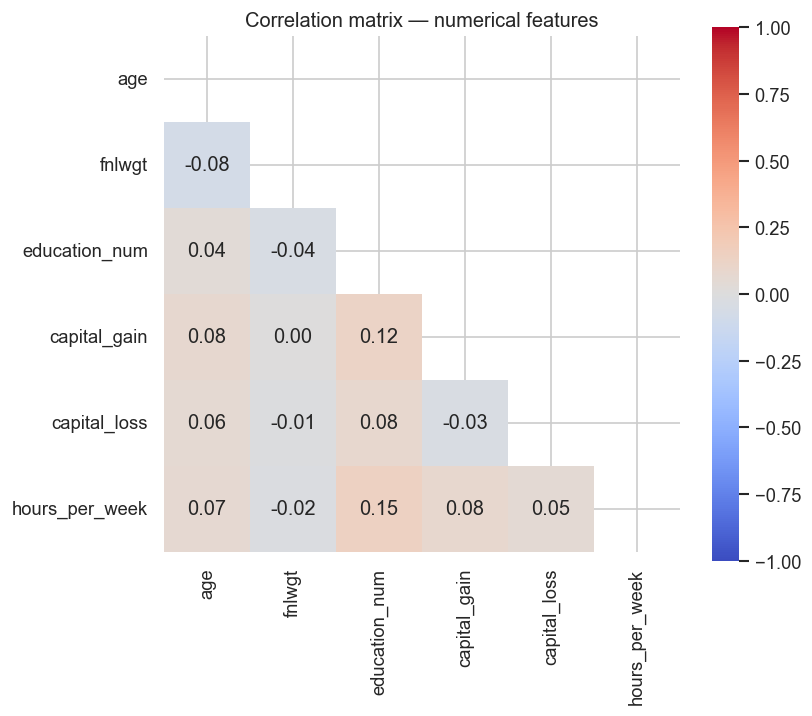

In [62]:
# Correlation matrix (numerical only)
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlation matrix — numerical features')
plt.tight_layout()
plt.show()

In [63]:
# Skewness — helpful for deciding whether to log-transform before scaling
skew = df[NUM_COLS].skew().sort_values(ascending=False)
print('Skewness:')
print(skew)

Skewness:
capital_gain     11.954
capital_loss      4.595
fnlwgt            1.447
age               0.559
hours_per_week    0.228
education_num    -0.312
dtype: float64


> **Note**: `capital_gain` and `capital_loss` are extremely right-skewed (most values are 0). Consider log1p transformation. `education` and `education_num` carry essentially the same information — one should likely be dropped.

## 6. Categorical Features

In [64]:
# Cardinality overview
print('Unique values per categorical feature:')
for col in CAT_COLS:
    n = df[col].nunique()
    print(f'  {col:<20} {n}')

Unique values per categorical feature:
  workclass            8
  education            16
  marital_status       7
  occupation           14
  relationship         6
  race                 5
  sex                  2
  native_country       41


In [65]:
# Value counts + income rate per category
def cat_income_summary(col, top_n=15):
    """Return a DataFrame with count and >50K rate for each category."""
    counts = df[col].value_counts().head(top_n)
    rate = (
        df.groupby(col)[TARGET]
        .apply(lambda s: (s == '>50K').mean())
        .reindex(counts.index)
    )
    return pd.DataFrame({'count': counts, '>50K rate': rate.round(3)})

for col in CAT_COLS:
    print(f'\n=== {col} ===')
    print(cat_income_summary(col))


=== workclass ===
                  count  >50K rate
workclass                         
Private           22696      0.219
Self-emp-not-inc   2541      0.285
Local-gov          2093      0.295
State-gov          1298      0.272
Self-emp-inc       1116      0.557
Federal-gov         960      0.386
Without-pay          14      0.000
Never-worked          7      0.000

=== education ===
              count  >50K rate
education                     
HS-grad       10501      0.160
Some-college   7291      0.190
Bachelors      5355      0.415
Masters        1723      0.557
Assoc-voc      1382      0.261
11th           1175      0.051
Assoc-acdm     1067      0.248
10th            933      0.066
7th-8th         646      0.062
Prof-school     576      0.734
9th             514      0.053
12th            433      0.076
Doctorate       413      0.741
5th-6th         333      0.048
1st-4th         168      0.036

=== marital_status ===
                       count  >50K rate
marital_status       

C:\Users\elisa\AppData\Local\Temp\ipykernel_11988\647262313.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
C:\Users\elisa\AppData\Local\Temp\ipykernel_11988\647262313.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
C:\Users\elisa\AppData\Local\Temp\ipykernel_11988\647262313.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
C:\Users\elisa\AppData\Local\Temp\ipykernel_11988\647262313.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

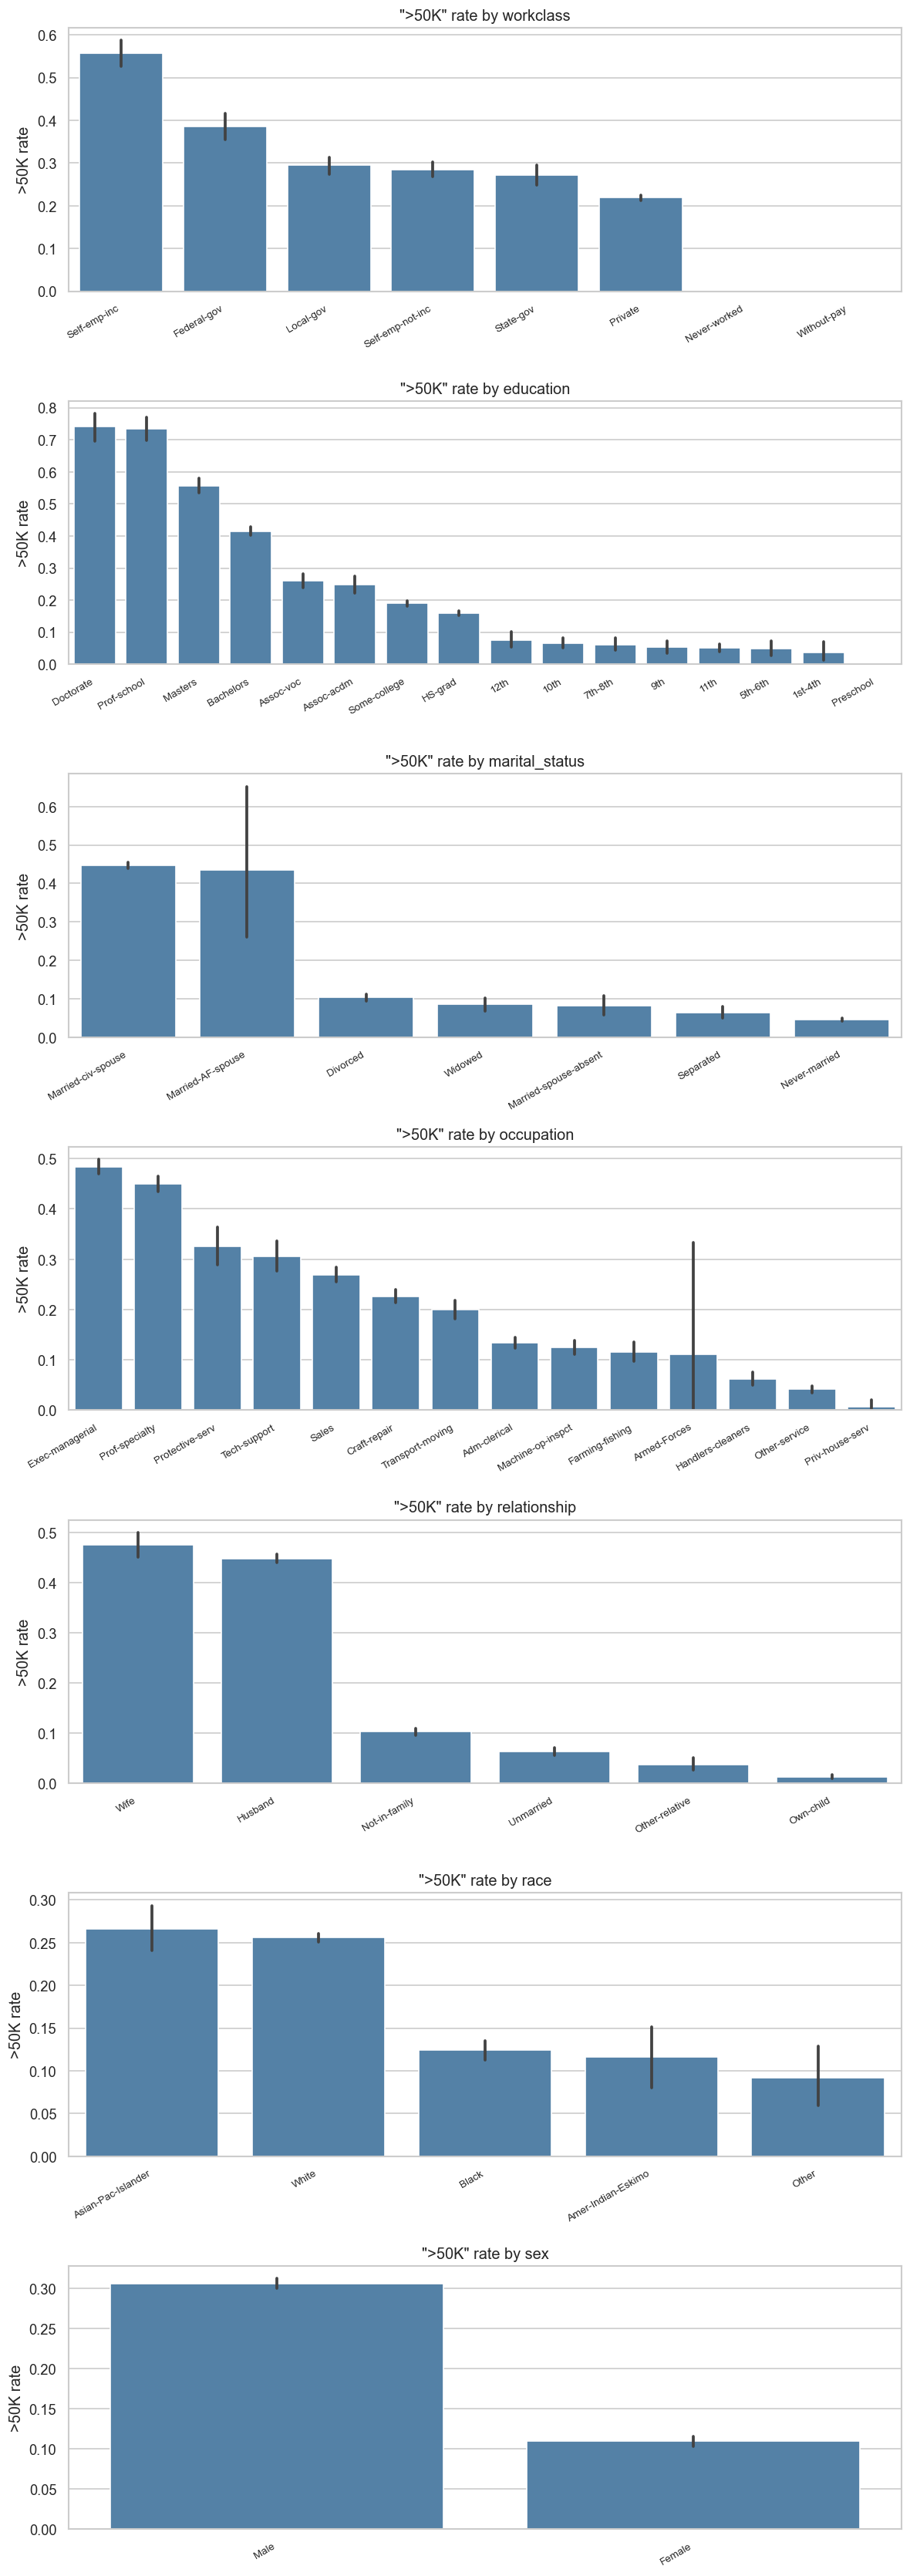

In [66]:
# Visual: >50K rate per category for selected features
PLOT_CATS = ['workclass', 'education', 'marital_status', 'occupation',
             'relationship', 'race', 'sex']

fig, axes = plt.subplots(len(PLOT_CATS), 1, figsize=(10, 4 * len(PLOT_CATS)))

for ax, col in zip(axes, PLOT_CATS):
    order = (
        df.groupby(col)[TARGET]
        .apply(lambda s: (s == '>50K').mean())
        .sort_values(ascending=False)
        .index
    )
    sns.barplot(data=df, x=col, y=(df[TARGET] == '>50K').astype(int),
                order=order, ax=ax, color='steelblue')
    ax.set_title(f'">50K" rate by {col}')
    ax.set_ylabel('>50K rate')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

## 7. Feature Relationships

In [67]:
# education vs education_num — check redundancy
edu_check = df.groupby('education')['education_num'].agg(['mean', 'std', 'nunique'])
print(edu_check.sort_values('mean'))

               mean   std  nunique
education                         
Preschool     1.000 0.000        1
1st-4th       2.000 0.000        1
5th-6th       3.000 0.000        1
7th-8th       4.000 0.000        1
9th           5.000 0.000        1
10th          6.000 0.000        1
11th          7.000 0.000        1
12th          8.000 0.000        1
HS-grad       9.000 0.000        1
Some-college 10.000 0.000        1
Assoc-voc    11.000 0.000        1
Assoc-acdm   12.000 0.000        1
Bachelors    13.000 0.000        1
Masters      14.000 0.000        1
Prof-school  15.000 0.000        1
Doctorate    16.000 0.000        1


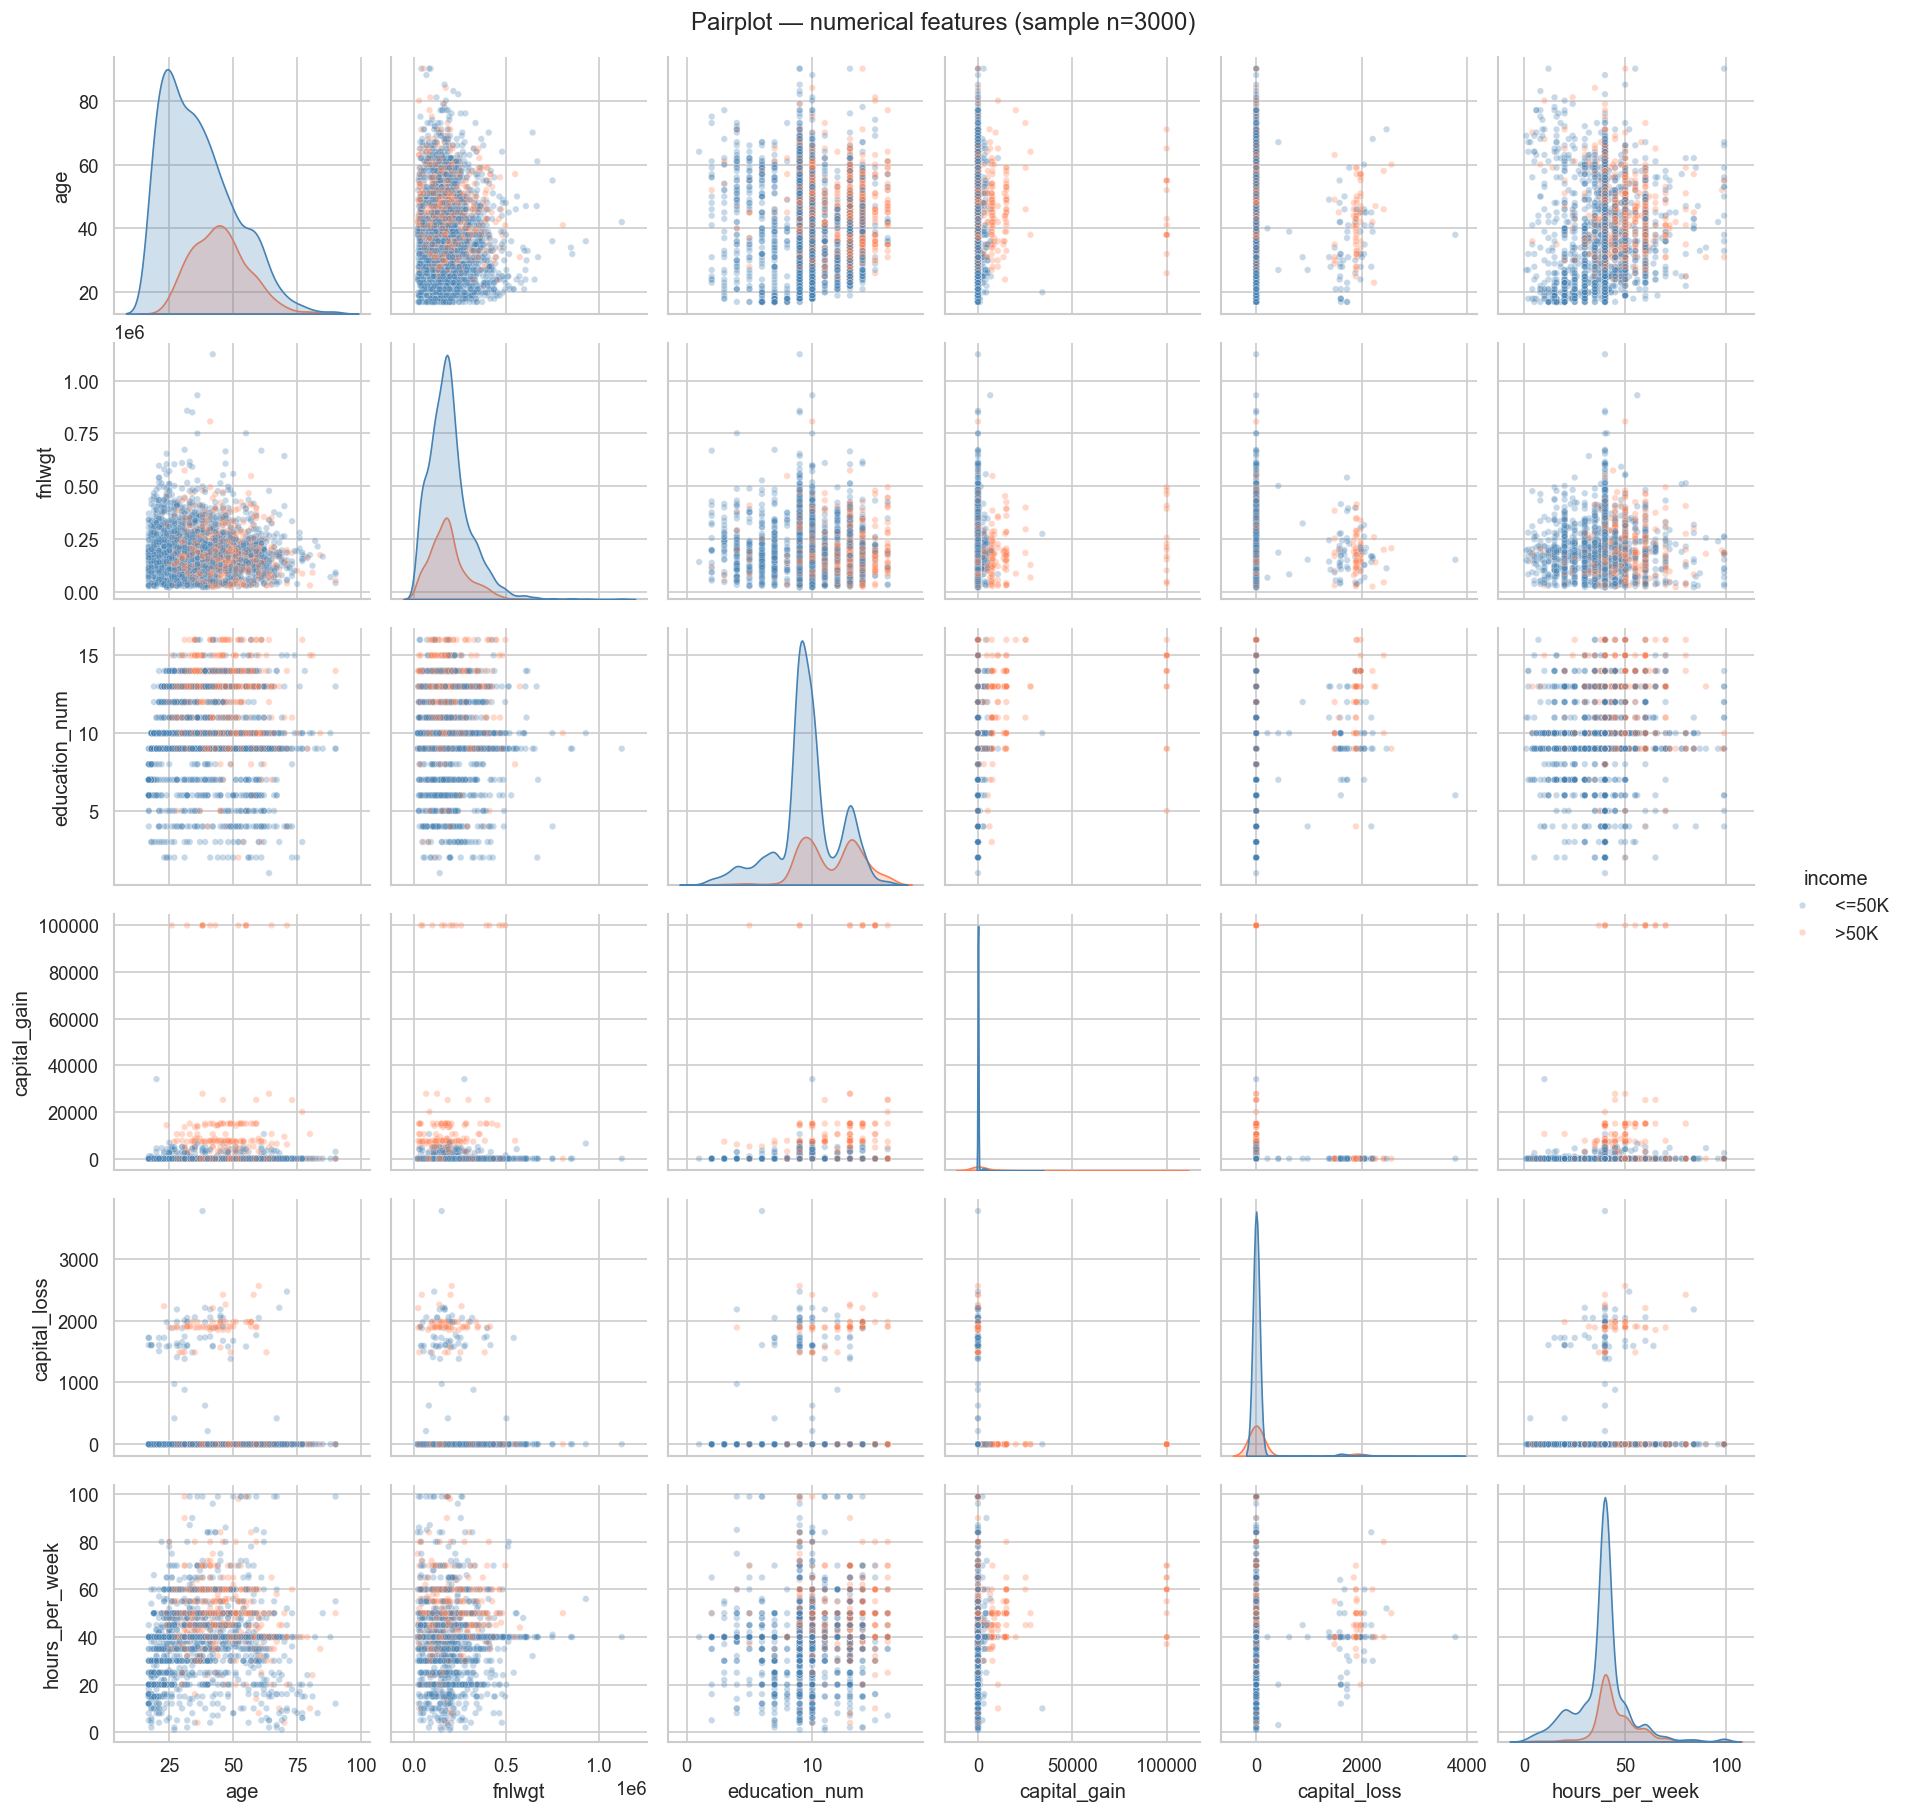

In [44]:
# Pairplot for key numerical features (sample to keep it fast)
sample = df.sample(n=3000, random_state=SEED)[NUM_COLS + [TARGET]]
g = sns.pairplot(sample, hue=TARGET, plot_kws={'alpha': 0.3, 's': 15},
                 palette=['steelblue', 'coral'])
g.fig.suptitle('Pairplot — numerical features (sample n=3000)', y=1.01)
plt.show()

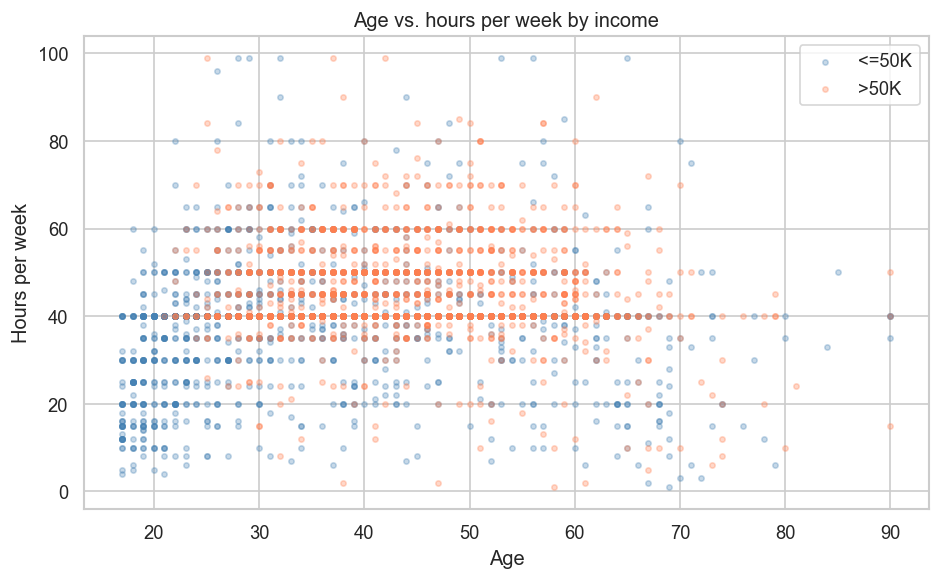

In [45]:
# Age × hours_per_week coloured by income
fig, ax = plt.subplots(figsize=(8, 5))
for label, color in [('<=50K', 'steelblue'), ('>50K', 'coral')]:
    sub = df[df[TARGET] == label].sample(n=2000, random_state=SEED)
    ax.scatter(sub['age'], sub['hours_per_week'], alpha=0.3, s=10,
               label=label, color=color)
ax.set_xlabel('Age')
ax.set_ylabel('Hours per week')
ax.set_title('Age vs. hours per week by income')
ax.legend()
plt.tight_layout()
plt.show()

In [46]:
# Point-biserial correlation between numerical features and binary target
df['income_bin'] = (df[TARGET] == '>50K').astype(int)

pb_corr = {}
for col in NUM_COLS:
    valid = df[[col, 'income_bin']].dropna()
    r, p = stats.pointbiserialr(valid['income_bin'], valid[col])
    pb_corr[col] = {'r': round(r, 3), 'p': round(p, 4)}

pb_df = pd.DataFrame(pb_corr).T.sort_values('r', ascending=False)
print('Point-biserial correlation with income:')
print(pb_df)

Point-biserial correlation with income:
                    r     p
education_num   0.335 0.000
age             0.234 0.000
hours_per_week  0.230 0.000
capital_gain    0.223 0.000
capital_loss    0.151 0.000
fnlwgt         -0.009 0.088


In [47]:
# Cramér's V for categorical features vs target
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

cv_scores = {col: cramers_v(df[col], df[TARGET]) for col in CAT_COLS}
cv_df = pd.Series(cv_scores).sort_values(ascending=False).to_frame('Cramers_V')
print('Cramér\'s V — categorical features vs income:')
print(cv_df.round(3))

Cramér's V — categorical features vs income:
                Cramers_V
relationship        0.454
marital_status      0.447
education           0.369
occupation          0.349
sex                 0.216
workclass           0.164
race                0.101
native_country      0.100


## 8. Preprocessing Notes

Based on the EDA above, here is a summary of decisions to revisit in the preprocessing phase:

| Issue | Affected features | Candidate strategy |
|---|---|---|
| Missing values (~7% of rows) | `workclass`, `occupation`, `native_country` | Impute mode / add indicator column |
| Redundant features | `education` vs `education_num` | Drop `education` (keep numerical) |
| High cardinality | `native_country` (41 categories) | Group rare countries, or target-encode |
| Right-skewed numerics | `capital_gain`, `capital_loss` | `log1p` before scaling |
| Class imbalance | Target (`income`) | Stratified splits; use F1, ROC-AUC, AUPR |
| `fnlwgt` relevance | Census weight — not a predictive feature per se | Consider dropping |
| Binary categorical | `sex` | Binary encoding (0/1) |
| Low-cardinality categoricals | `workclass`, `marital_status`, etc. | One-hot encoding |

In [48]:
# Quick sanity check before moving to preprocessing
print('Shape:', df.shape)
print('Target distribution:')
print(df[TARGET].value_counts(normalize=True).round(3))
print('\nDtypes:')
print(df.dtypes)

Shape: (32561, 16)
Target distribution:
income
<=50K   0.759
>50K    0.241
Name: proportion, dtype: float64

Dtypes:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
income_bin        int64
dtype: object
